# 01 — Exploratory Data Analysis
**Task:** predict `sleep_stage` (0=Wake, 1=Light, 2=Deep, 3=REM) per 30-s epoch. **Metric:** macro-F1 (every class equal — the weakest class drags the score).

This notebook only explores; it writes no model artifacts.

In [1]:
# --- Shared toolbox (identical across notebooks; see build_notebooks.py) ---
import warnings, json
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, classification_report, confusion_matrix

SEED = 42
N_FOLDS = 5
CLASS_NAMES = {0: "Wake", 1: "Light", 2: "Deep", 3: "REM"}
CLASSES = np.array([0, 1, 2, 3])
EOG = "eog_burst_index"            # the only column with missing values (~50%)

RAW_FEATURES = [
    "eeg_delta_power", "eeg_theta_power", "eeg_alpha_power", "eeg_sigma_power",
    "eeg_beta_power", "eeg_gamma_power", "eeg_slow_osc_power", "eeg_spectral_entropy",
    "eeg_spindle_density", "eeg_kcomplex_rate", "emg_chin_tone", "emg_tone_variance",
    "eog_movement_density", "eog_amplitude", "heart_rate_mean", "heart_rate_variability",
    "respiration_rate", "respiration_variability", "spo2_mean", "body_movement_index",
    EOG,
]
POWER = ["eeg_delta_power", "eeg_theta_power", "eeg_alpha_power", "eeg_sigma_power",
         "eeg_beta_power", "eeg_gamma_power", "eeg_slow_osc_power"]

HERE = Path.cwd()
ART = HERE / "artifacts"; ART.mkdir(exist_ok=True)
SUB = HERE / "submissions"; SUB.mkdir(exist_ok=True)


def load_data():
    """Return (train_df, test_df). Features kept as-is (NaN preserved)."""
    tr = pd.read_csv(HERE / "train.csv")
    te = pd.read_csv(HERE / "test.csv")
    return tr, te


def macro_f1(y_true, y_pred):
    """Competition metric: macro-averaged F1 over the 4 classes."""
    return f1_score(y_true, y_pred, average="macro")


def per_class_f1(y_true, y_pred):
    f = f1_score(y_true, y_pred, average=None, labels=CLASSES)
    return {CLASS_NAMES[c]: round(float(f[i]), 4) for i, c in enumerate(CLASSES)}


def softplus(x):
    """Numerically stable log(1+exp(x)); strictly positive and monotonic.
    Used to turn z-scored band powers (~50% negative) into positive magnitudes
    so band ratios are well-defined instead of dividing by near-zero."""
    x = np.asarray(x, dtype=float)
    return np.log1p(np.exp(-np.abs(x))) + np.maximum(x, 0.0)


def _aligned_proba(model, X):
    """predict_proba with columns aligned to CLASSES = [0,1,2,3]."""
    p = model.predict_proba(X)
    cls = list(np.asarray(model.classes_))
    idx = [cls.index(c) for c in CLASSES]
    return p[:, idx]


def run_oof(make_model, X, y, X_test, folds, needs_impute=False, use_eval_set=False):
    """Out-of-fold training under fixed folds.

    Returns (oof, test_p, oof_macro, fold_scores):
      oof     : (n_train, 4) out-of-fold probabilities (each row predicted once)
      test_p  : (n_test, 4) test probabilities, averaged over the 5 fold-models
      oof_macro: global macro-F1 over the assembled OOF matrix (primary metric)

    Two model families, identical folds:
      - CatBoost (needs_impute=False): NaN passed through natively.
      - sklearn trees (needs_impute=True): add EOG-missing flag + fill EOG NaN
        with the TRAIN-FOLD median (fit on train fold only -> no leakage)."""
    n = len(y)
    oof = np.zeros((n, len(CLASSES)))
    test_p = np.zeros((len(X_test), len(CLASSES)))
    fold_scores = []
    for tr_idx, va_idx in folds:
        Xtr, Xva, Xte = X.iloc[tr_idx].copy(), X.iloc[va_idx].copy(), X_test.copy()
        ytr, yva = y[tr_idx], y[va_idx]
        if needs_impute:
            med = Xtr[EOG].median()
            for d in (Xtr, Xva, Xte):
                if EOG + "_missing" not in d.columns:
                    d[EOG + "_missing"] = d[EOG].isna().astype("int8")
                d[EOG] = d[EOG].fillna(med)
            assert not Xtr.isna().any().any(), "NaN remained after impute"
        model = make_model()
        if use_eval_set:
            model.fit(Xtr, ytr, eval_set=(Xva, yva))
        else:
            model.fit(Xtr, ytr)
        oof[va_idx] = _aligned_proba(model, Xva)
        test_p += _aligned_proba(model, Xte) / len(folds)
        fold_scores.append(macro_f1(yva, oof[va_idx].argmax(1)))
    oof_macro = macro_f1(y, oof.argmax(1))
    return oof, test_p, oof_macro, fold_scores


def load_folds():
    """Load the fixed StratifiedKFold split saved by 02_baseline."""
    d = np.load(ART / "folds.npz", allow_pickle=True)
    return [(d[f"tr{i}"], d[f"va{i}"]) for i in range(N_FOLDS)]


In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
train, test = load_data()
print("train", train.shape, "| test", test.shape)
train.head()

train (9000, 23) | test (5000, 22)


,id,eeg_delta_power,eeg_theta_power,eeg_alpha_power,eeg_sigma_power,eeg_beta_power,eeg_gamma_power,eeg_slow_osc_power,eeg_spectral_entropy,eeg_spindle_density,...,eog_movement_density,eog_amplitude,heart_rate_mean,heart_rate_variability,respiration_rate,respiration_variability,spo2_mean,body_movement_index,eog_burst_index,sleep_stage
0,0,-1.51474,1.40728,10.33510,-1.61350,3.73081,0.99850,1.85689,-3.24253,-1.27096,...,2.65567,1.98733,1.60184,-2.49794,-0.59521,1.71154,1.93342,1.57365,-1.36230,1
1,1,-0.28998,0.89706,1.62494,2.41580,-2.70265,-0.10131,-1.68955,0.01442,-2.87943,...,4.36423,0.09942,3.38567,-0.56386,2.16016,-4.32301,1.07270,-2.43903,-0.37271,2
2,2,3.35435,0.32987,-5.41547,2.38680,-2.90584,-2.93372,-3.11713,-0.04647,1.61782,...,-3.87561,-0.87681,-2.84480,5.08383,-4.60411,0.37967,-2.06913,2.67324,NaN,3
3,3,-1.44917,-0.04374,1.71560,-1.27770,-0.19007,2.21826,1.69621,0.39756,0.00534,...,1.41415,0.39275,0.55060,-2.12910,2.32790,0.78319,0.98233,1.53824,-0.25040,1
4,4,1.35898,-2.36720,-7.40779,5.31815,-2.55954,-5.13284,-5.26634,1.73985,1.04618,...,-0.55616,0.86588,-1.96343,4.30036,0.22130,-1.44020,1.35760,-3.07701,-1.04947,3


## Class balance
Classes are nearly balanced, so a stratified split is enough. But macro-F1 still rewards fixing the *weakest* class, not overall accuracy.

{'Wake': 2001, 'Light': 2442, 'Deep': 2237, 'REM': 2320}


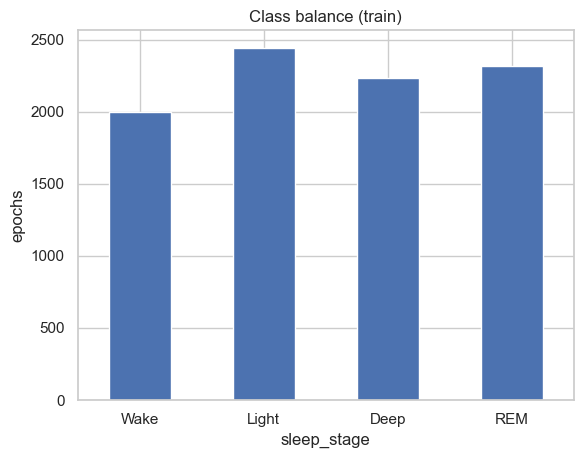

In [3]:
counts = train["sleep_stage"].value_counts().sort_index()
print({CLASS_NAMES[k]: int(v) for k, v in counts.items()})
ax = counts.rename(CLASS_NAMES).plot.bar(rot=0, title="Class balance (train)")
ax.set_ylabel("epochs"); plt.show()

## Missingness
`eog_burst_index` is the only column with missing values (~50% in both train and test). The EOG burst channel was simply off for some recordings, so *missingness is informative* — we add an `eog_burst_missing` flag and (for tree models that can't take NaN) impute with the train-fold median.

In [4]:
na = train.isna().sum(); print("train NaN:", na[na > 0].to_dict())
na_t = test.isna().sum(); print("test  NaN:", na_t[na_t > 0].to_dict())
# Does the channel being on/off relate to the stage?
m = train[EOG].isna().astype(int)
rate = train.groupby(m)["sleep_stage"].value_counts(normalize=True).unstack().round(3)
rate.index = ["channel ON", "channel OFF"]
print("\nclass distribution by EOG-channel availability:"); print(rate)

train NaN: {'eog_burst_index': 4501}


test  NaN: {'eog_burst_index': 2477}

class distribution by EOG-channel availability:
sleep_stage      0      1      2      3
channel ON   0.229  0.273  0.246  0.251
channel OFF  0.216  0.269  0.251  0.264


## Feature distributions by stage
Boxplots show which features separate stages. Expect high delta/slow-osc in Deep, theta + eye movement in REM, high EMG tone and movement in Wake.

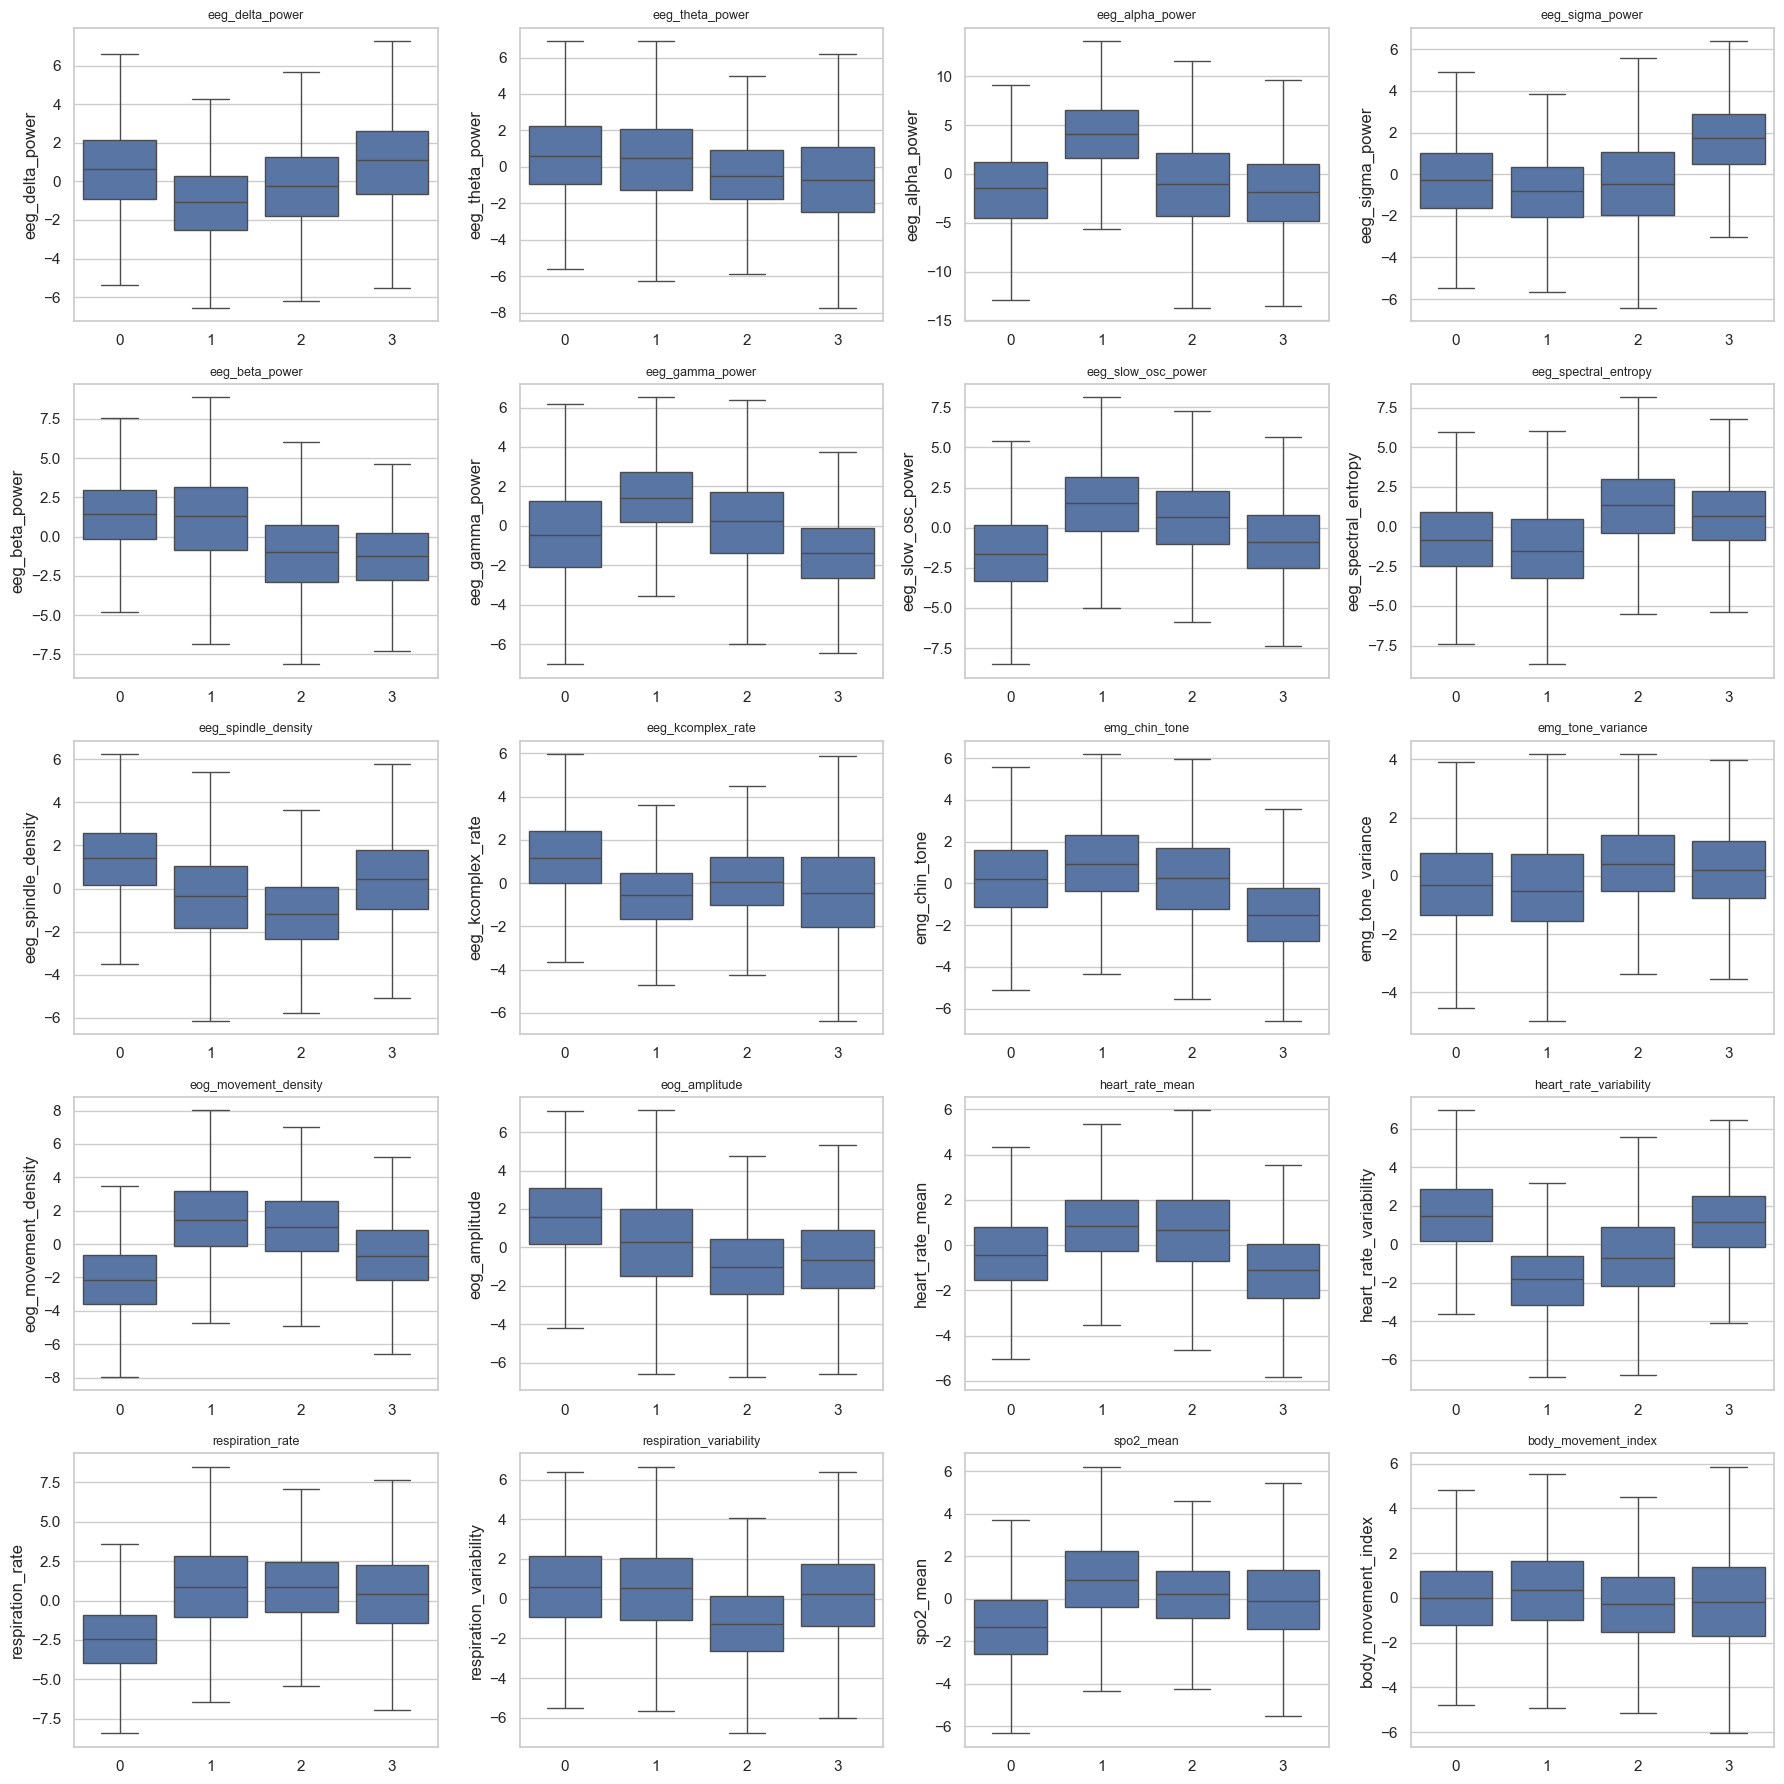

In [5]:
feats = [c for c in RAW_FEATURES if c != EOG]
fig, axes = plt.subplots(5, 4, figsize=(18, 18))
for ax, f in zip(axes.ravel(), feats):
    sns.boxplot(data=train, x="sleep_stage", y=f, ax=ax, showfliers=False)
    ax.set_title(f, fontsize=9); ax.set_xlabel("")
for ax in axes.ravel()[len(feats):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

## Correlation heatmap
Highly correlated band powers motivate the engineered contrasts/ratios in `03_features` (they capture *relative* power, which trees split on).

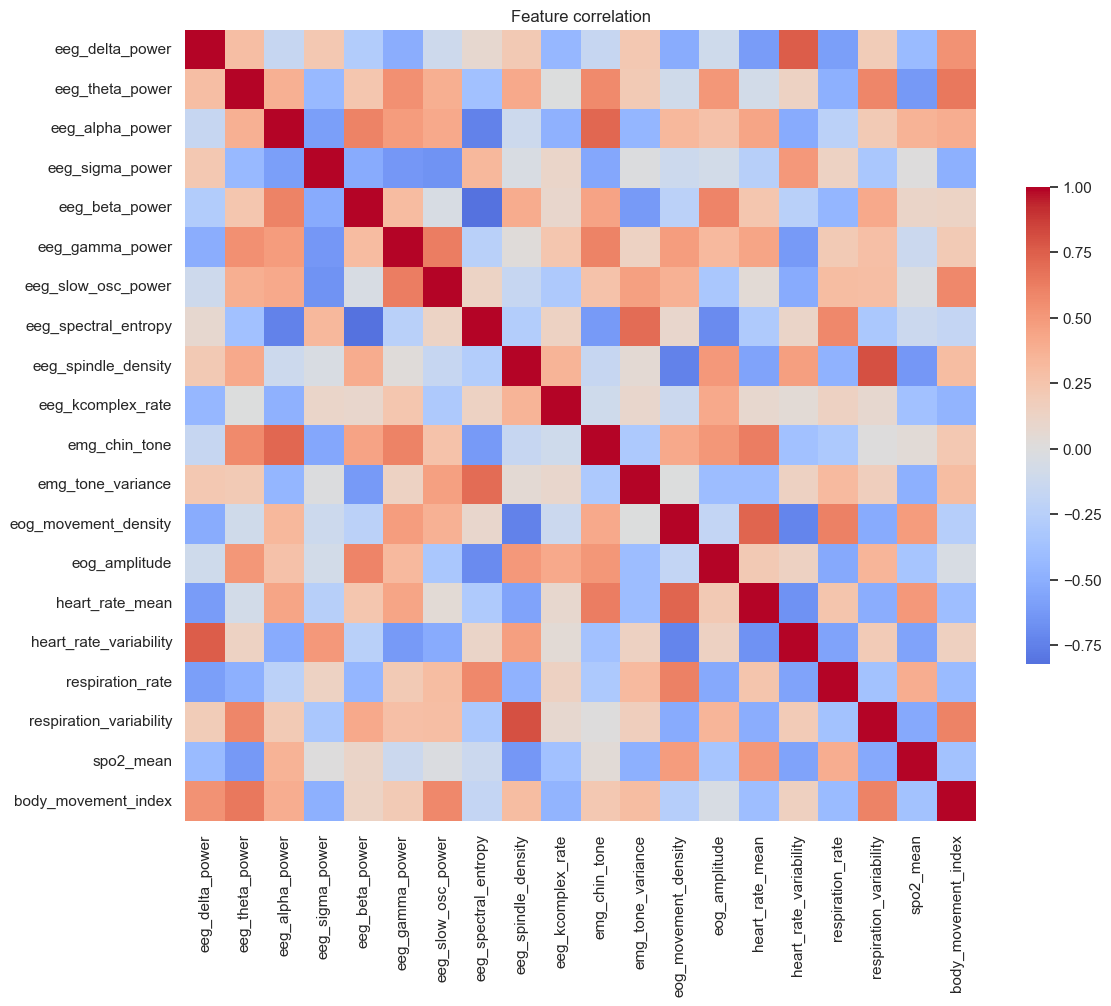

In [6]:
corr = train[feats].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": .6}, xticklabels=True, yticklabels=True)
plt.title("Feature correlation"); plt.tight_layout(); plt.show()

## Quick sanity model (OOB)
A bagged tree with out-of-bag scoring gives a cheap first read on signal strength before we build the proper CV pipeline.

In [7]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
Xq = train[feats].copy()          # drop EOG (NaN) for this quick check
yq = train["sleep_stage"].values
bag = BaggingClassifier(DecisionTreeClassifier(max_depth=None),
        n_estimators=200, oob_score=True, n_jobs=-1, random_state=SEED)
bag.fit(Xq, yq)
print("Bagging OOB accuracy:", round(bag.oob_score_, 4))
print("(accuracy only — macro-F1 via proper CV starts in 02_baseline)")

Bagging OOB accuracy: 0.7622
(accuracy only — macro-F1 via proper CV starts in 02_baseline)


### Takeaways
- 4 near-balanced classes → StratifiedKFold(5); optimize the weakest class.
- Only `eog_burst_index` is missing (~50%, informative) → flag + train-fold-median impute / native NaN.
- Band powers are z-scored and correlated → build z-score-safe contrasts/ratios in `03`.
- No id/recording grouping → plain stratified CV is valid (no leakage).